In [21]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
#Load Dataset
df = pd.read_csv('wfp_food_prices_zwe.csv')

In [7]:
#Preview the dataset
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (18141, 16)


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2010-01-15,NaN,NaN,Kombai,723,NaN,NaN,cereals and tubers,Maize,51,KG,actual,Retail,USD,0.26,0.26
1,2010-01-15,NaN,NaN,Mandava,722,NaN,NaN,cereals and tubers,Maize,51,KG,actual,Retail,USD,0.26,0.26
2,2010-01-15,NaN,NaN,Mucheke,719,NaN,NaN,cereals and tubers,Maize,51,KG,actual,Retail,USD,0.31,0.31
3,2010-01-15,NaN,NaN,Murombedzi,710,NaN,NaN,cereals and tubers,Maize,51,KG,actual,Retail,USD,0.23,0.23
4,2010-01-15,NaN,NaN,Tshovani,721,NaN,NaN,cereals and tubers,Maize,51,KG,actual,Retail,USD,0.29,0.29


In [11]:
# 2. Extract Month/Year for Seasonality & Trend
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

In [28]:
# 3. Select the columns YOU have
# Note: text fields are categorical and will be one-hot encoded
# numeric fields stay numeric
features = [
    'commodity', 'market', 'category', 'unit', 'pricetype', 'priceflag',
    'admin1', 'admin2',
    'month', 'year', 'latitude', 'longitude', 'market_id', 'commodity_id',
    'currency'
]

In [29]:
# 4. Prepare X (Features) and y (Target)
X = pd.get_dummies(df[features]) # This turns text into numbers automatically
y = df['usdprice'] # This is what we want to predict

In [30]:
# 5. Train Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [31]:
# Use the trained model to predict prices for your test set
y_pred = model.predict(X_test)

# Compare the first 10 predicted prices vs actual prices
comparison_df = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred[:10]})
print(comparison_df)

    Actual  Predicted
0  0.19000   0.194268
1  0.00210   0.058383
2  0.00190   0.006204
3  0.00160   0.008079
4  3.00000   2.723500
5  0.00110   0.000896
6  0.00011   0.005712
7  0.00070   0.008505
8  0.00019   0.000198
9  0.01400   0.002841


In [32]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Testing Results:")
print(f"Average Error (MAE): ${mae:.2f}")
print(f"R-Squared Accuracy: {r2:.2f}")

Testing Results:
Average Error (MAE): $0.06
R-Squared Accuracy: 0.85


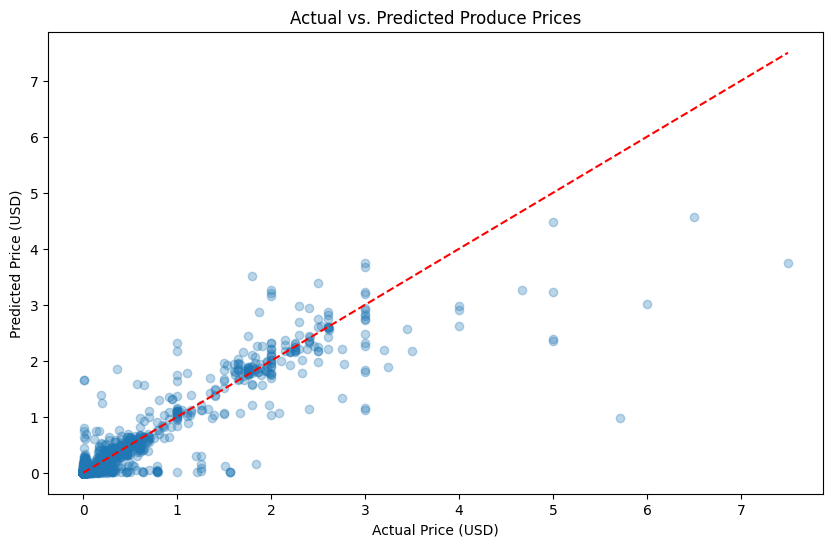

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs. Predicted Produce Prices')
plt.show()

In [19]:
# 6. Save Model and Column list (needed for FastAPI later)
joblib.dump(model, 'dynamic_pricing_model.pkl')
joblib.dump(list(X.columns), 'model_columns.pkl')

['model_columns.pkl']